# Autómatas celulares

## Ejercicio 2

__Enunciado:__ Suponga una enfermedad y desarrolle un modelo de difusión usando Autómatas celulares  probabilísticos.

## Elementos del autómata celular

* El Retículo (Universo): Se utilizará un arreglo regular bidimensional (2D) de $N \times N$ celdas.

* La Célula y el Alfabeto (Estados): Cada celda representa una porción de espacio que puede contener un individuo. El conjunto de estados $w$ será:

  * 0 (Vacío): No hay persona en esa cuadrícula
  * 1 (Sano/Susceptible): Persona sana que puede contagiarse.
  * 2 (Infectado): Persona enferma con capacidad de contagiar a sus vecinos.
  * 3 (Recuperado): Persona curada que ahora posee anticuerpos.

* La Vecindad: Se aplicará la vecindad de Moore (radio $r=1$), la cual incluye a los 8 vecinos que rodean a la célula central (N, NE, E, SE, S, SO, O, NO).

* Configuración Inicial: El retículo se carga poblando una gran mayoría de celdas con personas sanas (1) y un pequeño número aleatorio de pacientes cero infectados (2). El resto del espacio queda vacío (0).

## Reglas de Transición Probabilísticas

Todas las células se actualizan de manera paralela en cada ciclo de tiempo dependiendo de las siguientes reglas locales:
* Contagio: Si una célula central está en estado 1 (Sana) y tiene al menos un vecino en estado 2 (Infectado) dentro de su vecindad de Moore, existe una probabilidad $P_{inf}$ (ej. 30%) de que la célula sana pase a estado 2.
* Recuperación: Si una célula está en estado 2 (Infectado), tiene una probabilidad $P_{rec}$ (ej. 10%) en cada ciclo de pasar al estado 3
(Recuperado), simulando el tiempo que el cuerpo tarda en combatir el virus.

* Reinfección: El estado 3 (Recuperado) tiene una probabilidad muy baja de reinfectarse si tiene infectados en su vecindad de Moore debido a sus anticuerpos. tiene una probabilidad $P_{rec}$ (ej. 2%) en cada ciclo de pasar al estado 2
(Infectado)

* Estática: Los estados 0 (Vacío) se mantienen constantes y no cambian con la interacción.

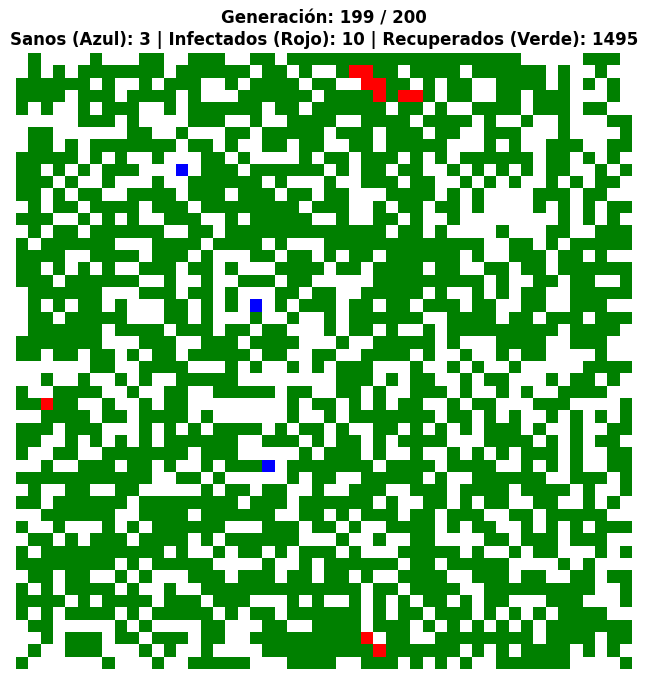

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import clear_output
import time

def inicializar_reticulo(N, prob_sano=0.6, prob_infectado=0.01):
    """Inicializa el retículo 2D (0: Vacío, 1: Sano, 2: Infectado, 3: Recuperado)."""
    reticulo = np.zeros((N, N), dtype=int)
    for i in range(N):
        for j in range(N):
            rand = np.random.rand()
            if rand < prob_infectado:
                reticulo[i, j] = 2
            elif rand < prob_sano + prob_infectado:
                reticulo[i, j] = 1
    return reticulo

def contar_vecinos_infectados(reticulo, x, y, N):
    """Cuenta vecinos en estado 2 (Infectado) usando vecindad de Moore."""
    infectados = 0
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            nx, ny = (x + dx) % N, (y + dy) % N
            if reticulo[nx, ny] == 2:
                infectados += 1
    return infectados

def actualizar_reticulo(reticulo, p_inf, p_rec, p_reinf, N):
    """Aplica las reglas del AC probabilístico para un ciclo."""
    nuevo_reticulo = reticulo.copy()

    for i in range(N):
        for j in range(N):
            estado_actual = reticulo[i, j]

            # Regla 1: Contagio de personas sanas
            if estado_actual == 1:
                vecinos_inf = contar_vecinos_infectados(reticulo, i, j, N)
                if vecinos_inf > 0:
                    prob_total_inf = 1 - ((1 - p_inf) ** vecinos_inf)
                    if np.random.rand() < prob_total_inf:
                        nuevo_reticulo[i, j] = 2

            # Regla 2: Recuperación de infectados
            elif estado_actual == 2:
                if np.random.rand() < p_rec:
                    nuevo_reticulo[i, j] = 3

            # Regla 3: Re-infección de recuperados (Pérdida de inmunidad)
            elif estado_actual == 3:
                vecinos_inf = contar_vecinos_infectados(reticulo, i, j, N)
                if vecinos_inf > 0:
                    # Probabilidad de reinfección muy baja
                    prob_total_reinf = 1 - ((1 - p_reinf) ** vecinos_inf)
                    if np.random.rand() < prob_total_reinf:
                        nuevo_reticulo[i, j] = 2

    return nuevo_reticulo

def simular_enfermedad_animada(N=50, ciclos=150, p_inf=0.3, p_rec=0.1, p_reinf=0.02, retardo=0.1):
    """
    Ejecuta la simulación con animación en tiempo real en Google Colab.
    """
    reticulo = inicializar_reticulo(N)

    cmap = mcolors.ListedColormap(['white', 'blue', 'red', 'green'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    for ciclo in range(ciclos):
        # Contar población actual
        sanos = np.sum(reticulo == 1)
        infectados = np.sum(reticulo == 2)
        recuperados = np.sum(reticulo == 3)

        # Limpiar la salida de la celda para el nuevo frame
        clear_output(wait=True)

        # Crear la gráfica
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(reticulo, cmap=cmap, norm=norm)

        # Título dinámico con estadísticas
        ax.set_title(f"Generación: {ciclo} / {ciclos}\n"
                     f"Sanos (Azul): {sanos} | Infectados (Rojo): {infectados} | Recuperados (Verde): {recuperados}",
                     fontsize=12, fontweight='bold')
        ax.axis('off')

        plt.show()

        # Romper el bucle si ya no hay infectados (la enfermedad se erradicó)
        if infectados == 0:
            print("La enfermedad ha sido erradicada. Simulación terminada.")
            break

        # Actualizar el retículo para la siguiente generación
        reticulo = actualizar_reticulo(reticulo, p_inf, p_rec, p_reinf, N)

        # Pausa para que la animación sea visible
        time.sleep(retardo)

# Parámetros ajustados para una epidemia larga:
# p_reinf=0.02 significa un 2% base de probabilidad de reinfección por cada vecino enfermo
simular_enfermedad_animada(N=50, ciclos=200, p_inf=0.35, p_rec=0.10, p_reinf=0.02, retardo=0.05)